In [1]:
import numpy as np
import os
import yaml
import seaborn as sns

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
!ls

 GB_node_array_homo_first.npy   Qity_Analysis.ipynb   trustnetwork.txt
'Granular Analysis.ipynb'       rating.txt	      trust.txt
 lastf_homo.png		        test.txt	      valid.txt
 lastfm_homo.pdf	        train.txt	      weighted_trust.txt


In [2]:
data_file='GB_node_array_homo_first.npy'
GB_node_array= np.load(data_file, allow_pickle=True)

In [3]:
num_user=1892

In [4]:
class TreeNode:
    def __init__(self, value,qity=None, is_center=True):
        self.value = value  # Center value or leaf value
        self.children = []
        self.qity=qity
        self.is_center = is_center  # To distinguish between center and leaf nodes

    def add_child(self, child_node):
        self.children.append(child_node)
        
def build_recursive_tree(cluster_data):
    root = TreeNode("Root", is_center=True)  # Root node

    def add_cluster_to_tree(cluster, parent_node):
        center_value, qity = cluster[1]  # Center node value
        center_node = TreeNode(center_value, qity, is_center=True)
        parent_node.add_child(center_node)

        for sub_cluster in cluster[0]:  # Check for sub-clusters
            if isinstance(sub_cluster, tuple):  # If it's a tuple, it's a cluster
                add_cluster_to_tree(sub_cluster, center_node)
            else:  # If it's a node, it's a leaf
                value = sub_cluster[:-1]
                _, qity = sub_cluster[-1]
                leaf_node = TreeNode(value, qity, is_center=False)
                center_node.add_child(leaf_node)

    for cluster in cluster_data:
        add_cluster_to_tree(cluster, root)

    return root

In [5]:
GB_node_list = [tuple(item) for item in GB_node_array]

tree = build_recursive_tree(GB_node_list)

In [6]:
GB_flatten=[]

In [7]:
def flatten__tree(node, centers=[]):
    # print(" " * level + str(node.value))  # Print node value
    if isinstance(node.value, list):
        GB_flatten.append(([user for user in node.value if user<num_user], centers + [(None, node.qity)]))
    else:
        for child in node.children:
            flatten__tree(child, centers + [(node.value, node.qity)])

In [8]:
flatten__tree(tree)

In [9]:
len(GB_flatten)

433

In [10]:
center_cluster={}
cluster_indices=[]
center_qity={}
centers_set=set()
for cluster, centers in GB_flatten:
    for center, qity in centers:
        if center==None:
            continue
        if center not in center_cluster:
            center_cluster[center]=[cluster]
        else:
            center_cluster[center].append(cluster)
for cluster, centers in GB_flatten:
    center_maxqity,qity=max(centers[1:-1], key=lambda x: x[1])
    centers_set.add(center_maxqity)
    if center_maxqity not in center_qity:
        center_qity[center_maxqity]=qity

In [11]:
len(centers_set)

377

In [16]:
qity_list=[center_qity[center]/2 for center in centers_set]

In [13]:
help(sns.histplot)

Help on function histplot in module seaborn.distributions:

histplot(data=None, *, x=None, y=None, hue=None, weights=None, stat='count', bins='auto', binwidth=None, binrange=None, discrete=None, cumulative=False, common_bins=True, common_norm=True, multiple='layer', element='bars', fill=True, shrink=1, kde=False, kde_kws=None, line_kws=None, thresh=0, pthresh=None, pmax=None, cbar=False, cbar_ax=None, cbar_kws=None, palette=None, hue_order=None, hue_norm=None, color=None, log_scale=None, legend=True, ax=None, **kwargs)
    Plot univariate or bivariate histograms to show distributions of datasets.
    
    A histogram is a classic visualization tool that represents the distribution
    of one or more variables by counting the number of observations that fall within
    disrete bins.
    
    This function can normalize the statistic computed within each bin to estimate
    frequency, density or probability mass, and it can add a smooth curve obtained
    using a kernel density estimate,

In [17]:
len(qity_list)

377

In [18]:
graph_qity=0.1026

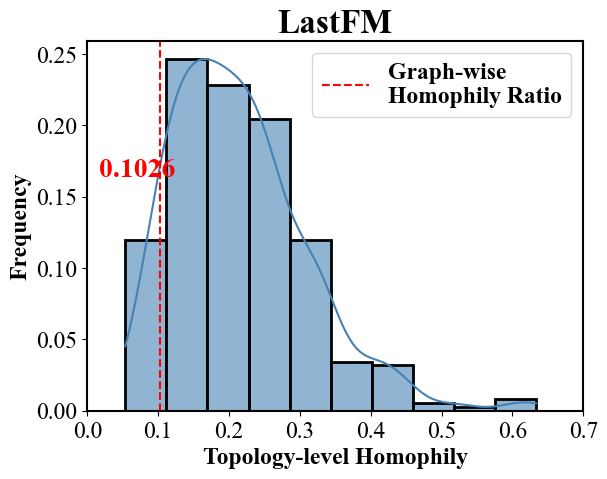

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Define font paths
font_paths = {
    'regular': '/usr/share/fonts/truetype/myfonts/Times New Roman.ttf',
    'bold': '/usr/share/fonts/truetype/myfonts/Times New Roman Bold.ttf',
}

# Create font properties using the custom fonts, adding bold weight
font_properties = {
    'regular': fm.FontProperties(fname=font_paths['regular'], size=17, weight='bold'),  # Increase size, bold
    'bold': fm.FontProperties(fname=font_paths['bold'], size=17, weight='bold'),  # Bold font
    'bold0': fm.FontProperties(fname=font_paths['bold'], size=24, weight='bold'),  # Larger and bold for title
}

# Global font size and weight setting for matplotlib
plt.rc('font', size=20, weight='bold')  # Set global font size and bold weight
plt.rc('axes', titlesize=28, labelsize=24, linewidth=2)  # Larger title and label sizes, thicker axis

# Create the histogram with KDE and thicker bar edges
sns.histplot(qity_list, bins=10, kde=True, stat='probability', color='#4682B4', alpha=0.6, 
             edgecolor='black', linewidth=2)  # Edge color and width for bars

# Add a vertical line at qity=0.0425
plt.axvline(x=graph_qity, color='red', linestyle='--', label='Graph-wise \nHomophily Ratio')

# Add labels and title, applying the custom bold fonts
plt.xlabel('Topology-level Homophily', fontproperties=font_properties['bold'])
plt.ylabel('Frequency', fontproperties=font_properties['bold'])
plt.title('LastFM', fontproperties=font_properties['bold0'])

# Add text for qity value, make it bold
plt.text(0.07, 0.16, f'{graph_qity:.4f}', color='red', fontsize=20, ha='center',
         fontproperties=font_properties['bold'], va='bottom')

# Customize the legend to use the bold font
plt.legend(prop=font_properties['bold'])
x_ticks = np.arange(0, 0.8, 0.1)  # Change the range and step as needed
y_ticks = np.arange(0, 0.3, 0.05)  # Adjust this based on your data's y-axis range

plt.xticks(x_ticks, fontproperties=font_properties['regular'])  # Set x-axis tick labels
plt.yticks(y_ticks, fontproperties=font_properties['regular']) 
# Set x and y ticks with Times New Roman bold font and increased size
#plt.xticks(fontproperties=font_properties['regular'])  # Set x-axis tick labels
#plt.yticks(fontproperties=font_properties['regular']) # Set y-axis tick labels # Customize the plot border thickness 
ax = plt.gca() 
for spine in ax.spines.values(): 
    spine.set_linewidth(1.5) # Set border thickness # Save the plot with tight layout 
plt.savefig('lastfm_homo.jpg', format='jpg', dpi=1000, bbox_inches='tight') # Show the plot 
plt.show()

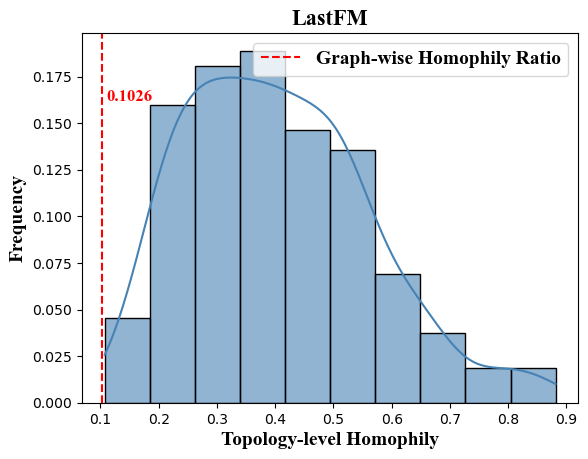

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Define font paths
font_paths = {
    'regular': '/usr/share/fonts/truetype/myfonts/Times New Roman.ttf',
    'bold': '/usr/share/fonts/truetype/myfonts/Times New Roman Bold.ttf',
}

# Create font properties using the custom fonts
font_properties = {
    'regular': fm.FontProperties(fname=font_paths['regular'], size=12),
    'bold': fm.FontProperties(fname=font_paths['bold'], size=14),
    'bold0': fm.FontProperties(fname=font_paths['bold'], size=16),
}


# Create the histogram with KDE
sns.histplot(qity_list, bins=10, kde=True, stat='probability', color='#4682B4', alpha=0.6)

# Add a vertical line at qity=0.0425
plt.axvline(x=graph_qity, color='red', linestyle='--', label='Graph-wise Homophily Ratio')
# Add labels and title, applying the custom fonts
plt.xlabel('Topology-level Homophily', fontproperties=font_properties['bold'])
plt.ylabel('Frequency', fontproperties=font_properties['bold'])
plt.title('LastFM', fontproperties=font_properties['bold0'])
plt.text(0.15, 0.16, f'{graph_qity:.4f}', color='red', fontsize=12,
        ha='center', fontproperties=font_properties['bold'], va='bottom')
#plt.text(graph_qity, 0.1, 'graph qity', color='red', fontsize=12, 
#         ha='center', fontproperties=font_properties['bold'], va='bottom')
# Customize the legend to use the bold font
plt.legend(prop=font_properties['bold'])
plt.savefig('lastf_homo.png', format='png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

In [50]:
help(plt.text)

Help on function text in module matplotlib.pyplot:

text(x, y, s, fontdict=None, **kwargs)
    Add text to the Axes.
    
    Add the text *s* to the Axes at location *x*, *y* in data coordinates.
    
    Parameters
    ----------
    x, y : float
        The position to place the text. By default, this is in data
        coordinates. The coordinate system can be changed using the
        *transform* parameter.
    
    s : str
        The text.
    
    fontdict : dict, default: None
        A dictionary to override the default text properties. If fontdict
        is None, the defaults are determined by `.rcParams`.
    
    Returns
    -------
    `.Text`
        The created `.Text` instance.
    
    Other Parameters
    ----------------
    **kwargs : `~matplotlib.text.Text` properties.
        Other miscellaneous text parameters.
    
        Properties:
        agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and t

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

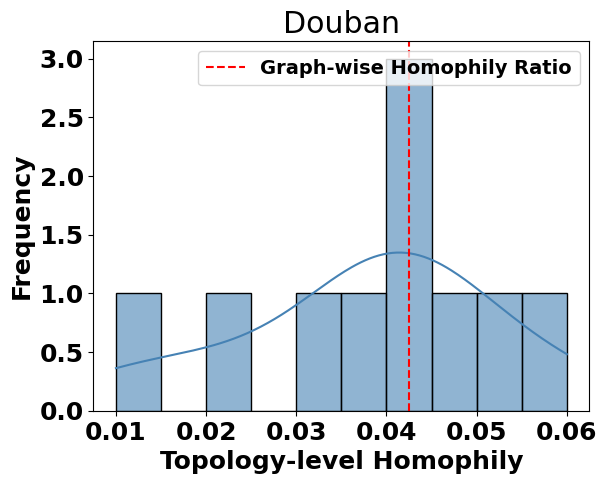

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib import rcParams
 
 
font_paths = {
    'regular': '/usr/share/fonts/truetype/myfonts/Times New Roman.ttf',
    'bold': '/usr/share/fonts/truetype/myfonts/Times New Roman Bold.ttf',
}
font_properties = {
    'regular': fm.FontProperties(fname=font_paths['regular']),
    'bold': fm.FontProperties(fname=font_paths['bold'], size=22),
    'bold0': fm.FontProperties(fname=font_paths['bold'], size=20),
}
 
sns.histplot(qity_list, bins=10, kde=True, color='#4682B4', alpha=0.6)

# Add a vertical line at qity=0.0425
plt.axvline(x=0.0425, color='red', linestyle='--', label='Graph-wise Homophily Ratio')

# Add labels and title
plt.xlabel('Topology-level Homophily')
plt.ylabel('Frequency')
plt.title('Douban')

# Display the legend
plt.legend()

# Show the plot
plt.show()

<Axes: ylabel='Count'>

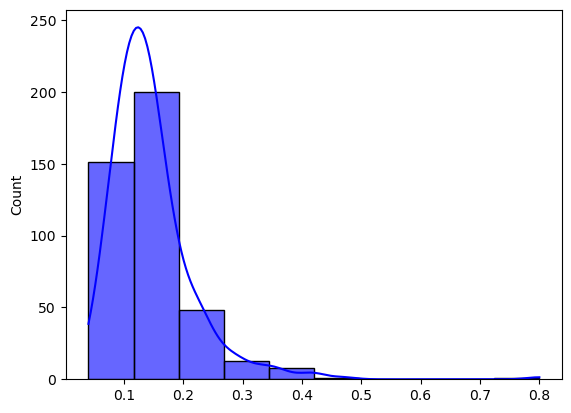

In [24]:
sns.histplot(qity_list, bins=10, kde=True, color='blue', alpha=0.6)

In [18]:
GB_node_len=[len([node for node in GB[0] if node<2817]) for GB in GB_flatten]

<Axes: ylabel='Count'>

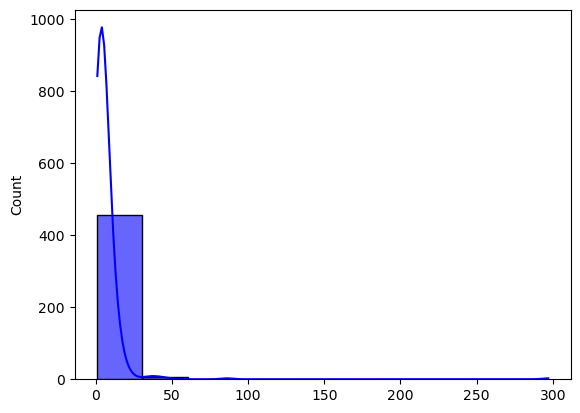

In [23]:
sns.histplot(GB_node_len, bins=10, kde=True, color='blue', alpha=0.6)

In [13]:
GB_node_len=[len([node for node in GB[0] if node<2817]) for GB in GB_flatten]

In [14]:
min(GB_node_len)

1

<AxesSubplot:ylabel='Count'>

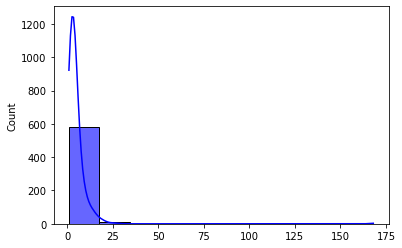

In [15]:
sns.histplot(GB_node_len, bins=10, kde=True, color='blue', alpha=0.6)

In [16]:
sorted(GB_node_len, reverse=True)

[168,
 27,
 24,
 21,
 20,
 20,
 19,
 18,
 18,
 17,
 17,
 17,
 16,
 16,
 15,
 15,
 15,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 14,
 13,
 13,
 13,
 13,
 13,
 12,
 12,
 12,
 12,
 12,
 12,
 11,
 11,
 11,
 11,
 11,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 9,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,

In [17]:
len(GB_node_len)

341

In [18]:
sum(GB_node_len)

2817

In [15]:
max(GB_node_len)

239

In [14]:
len(GB_node_array[1][0])

1

In [268]:
len([length for length in GB_node_len if length==2])

134

In [269]:
GB_node_array[1][0][1]

([([[19974,
     22536,
     17421,
     9233,
     21010,
     23,
     8221,
     15397,
     23081,
     3625,
     5682,
     17458,
     564,
     20022,
     16961,
     21061,
     584,
     11848,
     14413,
     21590,
     13912,
     6750,
     24159,
     2144,
     22624,
     3688,
     17001,
     15468,
     17010,
     9848,
     642,
     24708,
     18054,
     14470,
     4752,
     657,
     20119,
     19101,
     17573,
     17062,
     18601,
     8873,
     20657,
     1203,
     21180,
     14018,
     20164,
     1223,
     17098,
     15059,
     14551,
     6873,
     24286,
     1762,
     20707,
     14569,
     746,
     17643,
     256,
     8449,
     2819,
     1289,
     24332,
     7436,
     15635,
     789,
     18204,
     11552,
     17700,
     5925,
     1320,
     1834,
     21300,
     14135,
     13116,
     24895,
     5439,
     1349,
     20809,
     17742,
     24914,
     23892,
     15192,
     862,
     13153,
     7015,
     879,
 